# Analyse Exploratoire des Données — CropYield Prediction Dataset

**Objectif** : caractériser les quatre fichiers sources et repérer ce qui contraindra leur fusion.

**Données** : `data/crop-yield-prediction/`

| Fichier | Une ligne | Colonnes utiles | Période | Pays |
|---|---|---|---|---|
| `pesticides.csv` | pays × année | `Area`, `Year`, `Value` (tonnes de matière active) | 1990-2016 | 168 |
| `rainfall.csv` | pays × année | `Area`, `Year`, `average_rain_fall_mm_per_year` | 1985-2017 | 217 |
| `temp.csv` | pays × année × relevé | `country`, `year`, `avg_temp` | 1743-2013 | 137 |
| `yield.csv` | pays × culture × année | `Area`, `Item`, `Year`, `Value` (hg/ha) | 1961-2016 | 212 |
| `yield_df.csv` | fusion des quatre | — | 1990-2013 | 101 |

# Imports


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from agritech import geo, profile, utils
from agritech.config import PATHS

# Lecture du dataset

In [2]:
files_dir = PATHS.data_crop_yield_prediction
fichiers = ["pesticides.csv", "rainfall.csv", "temp.csv", "yield.csv", "yield_df.csv"]

manquants = [nom for nom in fichiers if not (files_dir / nom).is_file()]
print("fichiers manquants :", manquants or "aucun")

fichiers manquants : aucun


In [3]:
df_pesticides = pd.read_csv(files_dir / "pesticides.csv")
df_rainfall = pd.read_csv(files_dir / "rainfall.csv")
df_temp = pd.read_csv(files_dir / "temp.csv")
df_yield = pd.read_csv(files_dir / "yield.csv")
df_yield_df = pd.read_csv(files_dir / "yield_df.csv")

# rainfall.csv a une espace initiale dans l'en-tête de sa colonne pays
df_rainfall.columns = df_rainfall.columns.str.strip()

## pesticides.csv
Features utiles : 'Area' (pays), 'Year' (1990-2016), 'Value' (tonnes of active ingredients)

In [4]:
df_pesticides.head()

,Domain,Area,Year,Element,Item,Unit,Value
0,Pesticides Use,Albania,1990,Use,Pesticides (total),tonnes of active ingredients,121.0
1,Pesticides Use,Albania,1991,Use,Pesticides (total),tonnes of active ingredients,121.0
2,Pesticides Use,Albania,1992,Use,Pesticides (total),tonnes of active ingredients,121.0
3,Pesticides Use,Albania,1993,Use,Pesticides (total),tonnes of active ingredients,121.0
4,Pesticides Use,Albania,1994,Use,Pesticides (total),tonnes of active ingredients,201.0


In [5]:
p_pesticides = profile.profile_report(df_pesticides, PATHS.docs / "eda_pesticides_rapport.html")

Observations       : 4,349
Variables          : 7
Cellules manquantes: 0 (0.00%)
Lignes dupliquees  : 0 (0.00%)
Taille en memoire  : 0.2 Mo
Types              : {'Text': 5, 'Numeric': 2}

Alertes :
 - [Domain] has a constant value
 - [Element] has a constant value
 - [Item] has a constant value
 - [Unit] has a constant value


In [6]:
print("Pays : ", df_pesticides["Area"].nunique())
print(f"Années : {min(df_pesticides.Year)}-{max(df_pesticides.Year)} ({df_pesticides.Year.nunique()} distinctes)")
print(f"Valeurs : {min(df_pesticides.Value)} - {max(df_pesticides.Value)} (moyenne : {df_pesticides.Value.mean()})")
print("   -> Nombre à 0 : ",len(df_pesticides[df_pesticides.Value == 0]))
print("   -> Nombre < 0.1 : ",len(df_pesticides[(df_pesticides.Value < 0.1) & (df_pesticides.Value > 0)]))

Pays :  168
Années : 1990-2016 (27 distinctes)
Valeurs : 0.0 - 1807000.0 (moyenne : 20303.34146470453)
   -> Nombre à 0 :  2
   -> Nombre < 0.1 :  25


### Distributions

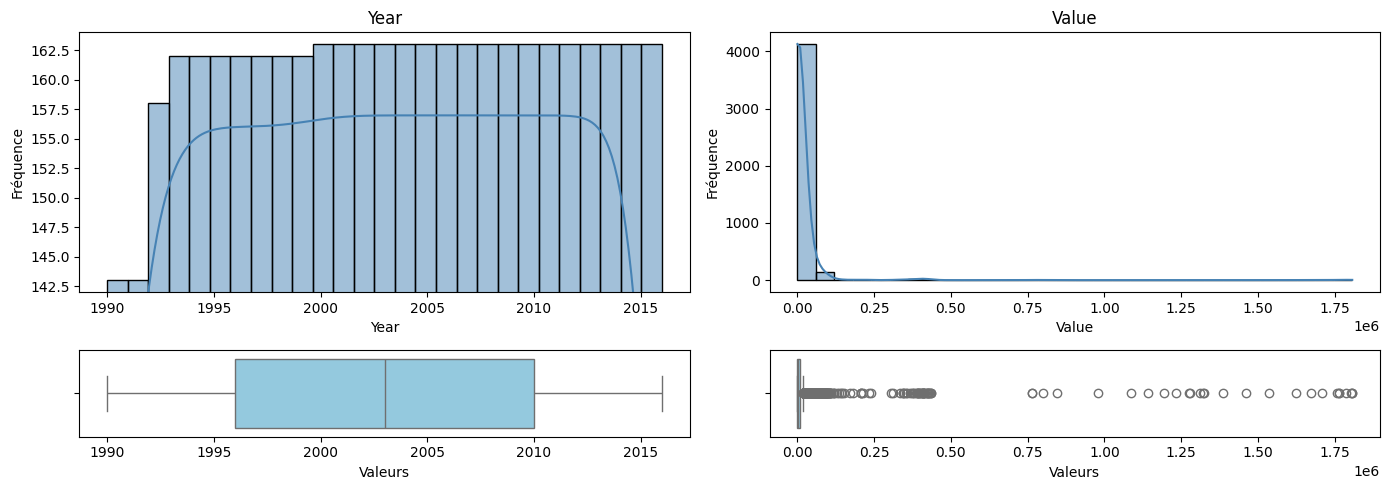

In [7]:
# une barre par année : sinon des intervalles tombent entre deux années entières
utils.plot_distribs(df_pesticides, ["Year", "Value"], bins={"Year": df_pesticides["Year"].nunique()})

### Pays les plus consomateurs

In [8]:
df_country = (
    df_pesticides.groupby(["Area", "Year"], as_index=False)["Value"]
      .mean()
)

df_country_mean = (
    df_country.groupby("Area", as_index=False)["Value"]
              .mean()
              .sort_values("Value", ascending=False)
)

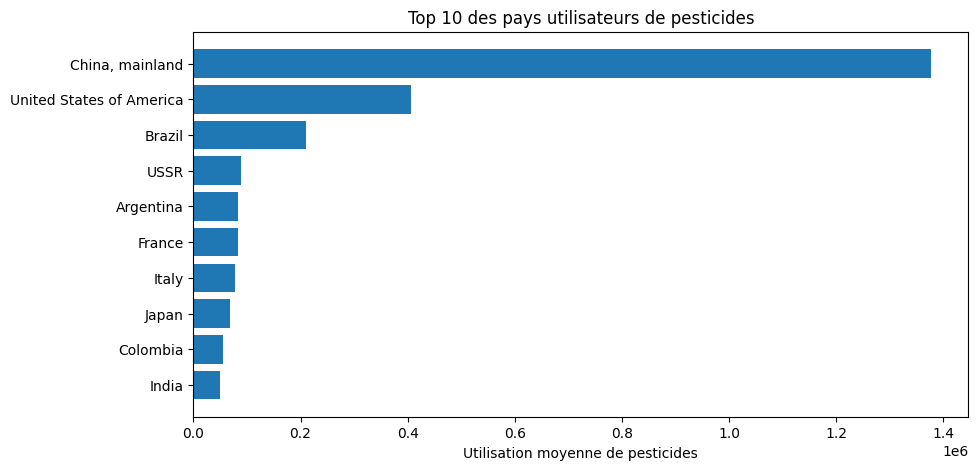

In [9]:
top10 = df_country_mean.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10["Area"], top10["Value"])
plt.xlabel("Utilisation moyenne de pesticides")
plt.title("Top 10 des pays utilisateurs de pesticides")
plt.gca().invert_yaxis()
plt.show()

In [10]:
df_country_stats = (
    df_pesticides
    .groupby("Area")["Value"]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

df_country_stats.head(10)

,mean,median,max
Area,,,
"China, mainland",1.377587e+06,1325226.00,1807000.00
United States of America,4.066033e+05,407779.20,434540.76
Brazil,2.100575e+05,182446.00,395646.00
USSR,8.920000e+04,89200.00,92200.00
Argentina,8.333572e+04,64568.95,207706.00
France,8.327432e+04,78577.00,114695.00
Italy,7.826321e+04,80454.00,100596.40
Japan,6.826507e+04,67869.72,79821.18
Colombia,5.486039e+04,52883.00,117881.45


**Observations :**

- Forte variabilité entre pays.
- Les valeurs brutes dépendent aussi de la taille du pays et des surfaces agricoles.
- Ces classements donnent surtout un ordre de grandeur.

### Utilisation moyenne de pesticides

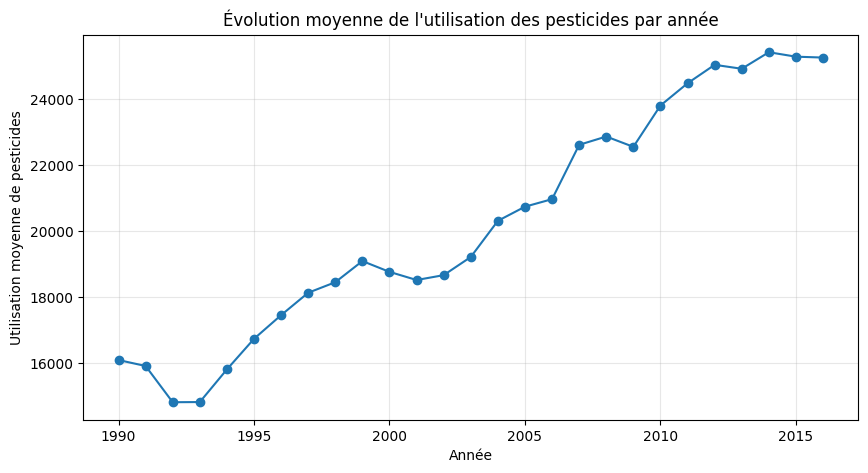

In [11]:
annual_mean = (
    df_pesticides
    .groupby("Year", as_index=False)["Value"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(annual_mean["Year"], annual_mean["Value"], marker="o")
plt.xlabel("Année")
plt.ylabel("Utilisation moyenne de pesticides")
plt.title("Évolution moyenne de l'utilisation des pesticides par année")
plt.grid(alpha=0.3)
plt.show()

## rainfall.csv

In [12]:
df_rainfall

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327
...,...,...,...
6722,Zimbabwe,2013,657
6723,Zimbabwe,2014,657
6724,Zimbabwe,2015,657
6725,Zimbabwe,2016,657


In [13]:
p_rainfall = profile.profile_report(df_rainfall, PATHS.docs / "eda_rainfall_rapport.html")

Observations       : 6,727
Variables          : 3
Cellules manquantes: 774 (3.84%)
Lignes dupliquees  : 0 (0.00%)
Taille en memoire  : 0.2 Mo
Types              : {'Text': 2, 'Numeric': 1}

Alertes :
 - [average_rain_fall_mm_per_year] 774 (11.5%) missing values


In [14]:
df_rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Area                           6727 non-null   object
 1   Year                           6727 non-null   int64 
 2   average_rain_fall_mm_per_year  5953 non-null   object
dtypes: int64(1), object(2)
memory usage: 157.8+ KB


### Conversion de la colonne de précipitations

La colonne est lue en `object`. On regarde ce qui bloque avant de convertir.

In [15]:
col_pluie = "average_rain_fall_mm_per_year"

converti = pd.to_numeric(df_rainfall[col_pluie], errors="coerce")
non_numeriques = converti.isna() & df_rainfall[col_pluie].notna()

print("NaN déjà lus par pandas  :", df_rainfall[col_pluie].isna().sum())
print("valeurs non convertibles :", df_rainfall.loc[non_numeriques, col_pluie].value_counts().to_dict())

df_rainfall[col_pluie] = converti

print(f"\nNaN après conversion     : {df_rainfall[col_pluie].isna().sum()} "
      f"({df_rainfall[col_pluie].isna().mean():.1%})")
print(f"min / max / moyenne      : {df_rainfall[col_pluie].min():.0f} / "
      f"{df_rainfall[col_pluie].max():.0f} / {df_rainfall[col_pluie].mean():.0f}")

NaN déjà lus par pandas  : 774
valeurs non convertibles : {'..': 6}

NaN après conversion     : 780 (11.6%)
min / max / moyenne      : 51 / 3240 / 1125


**Observations :**

- Un seul motif bloque la conversion : `..`, sur **6 lignes**. Les 774 autres manquants étaient déjà lus comme `NaN`.
- La conversion fait donc passer de 774 à **780 NaN (11,6 %)** : 6 valeurs nouvellement manquantes, rien de masqué.
- Colonne exploitable ensuite : 51 à 3 240 mm/an, moyenne 1 125.

In [16]:
rainfall_missing = (
    df_rainfall
    .assign(
        missing=df_rainfall["average_rain_fall_mm_per_year"].isna()
    )
    .groupby("Year", as_index=False)["missing"]
    .sum()
)

rainfall_missing.sort_values("missing", ascending=False).head(10)

,Year,missing
0,1985,26
1,1986,26
3,1989,26
4,1990,26
5,1991,26
24,2011,25
20,2007,25
21,2008,25
22,2009,25
23,2010,25


In [17]:
rainfall_missing_country = (
    df_rainfall
    .assign(missing=df_rainfall[col_pluie].isna())
    .groupby("Area")["missing"]
    .agg(["sum", "count"])
)

rainfall_missing_country["missing_rate"] = (
    rainfall_missing_country["sum"] / rainfall_missing_country["count"]
)

rainfall_missing_country = rainfall_missing_country.sort_values("missing_rate", ascending=False)

print("pays avec au moins un manquant :", (rainfall_missing_country["sum"] > 0).sum(),
      "/", len(rainfall_missing_country))
print("pays entièrement manquants     :", (rainfall_missing_country["missing_rate"] == 1).sum())
rainfall_missing_country.head(10)

pays avec au moins un manquant : 26 / 217
pays entièrement manquants     : 25


,sum,count,missing_rate
Area,,,
New Caledonia,31,31,1.0
Turks and Caicos Islands,31,31,1.0
Tonga,31,31,1.0
British Virgin Islands,31,31,1.0
Isle of Man,31,31,1.0
Cayman Islands,31,31,1.0
Channel Islands,31,31,1.0
St. Martin (French part),31,31,1.0
"Hong Kong SAR, China",31,31,1.0


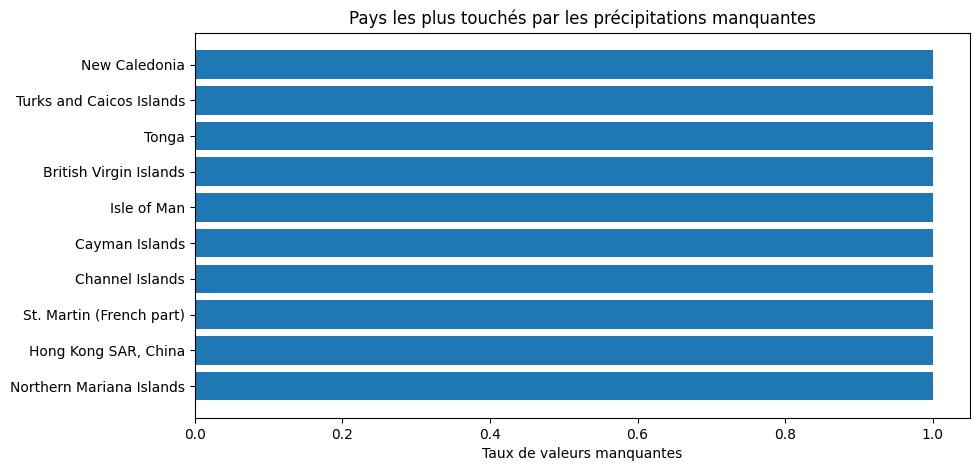

In [18]:
top_manquants = rainfall_missing_country.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_manquants.index, top_manquants["missing_rate"])
plt.xlabel("Taux de valeurs manquantes")
plt.title("Pays les plus touchés par les précipitations manquantes")
plt.gca().invert_yaxis()
plt.show()

**Observations :**

- Manquants concentrés sur quelques petits territoires : **26 pays sur 217** concernés, dont **25 sans aucune valeur** sur les 31 années.
- Monaco est le seul cas partiel, à 96,8 %.
- Les 191 autres pays sont complets.
- Décision à prendre au moment de la fusion, selon la présence de ces territoires dans les autres sources. Rien n'est supprimé ici.

## temp.csv

In [19]:
df_temp

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN
...,...,...,...
71306,2009,Mexico,21.76
71307,2010,Mexico,20.90
71308,2011,Mexico,21.55
71309,2012,Mexico,21.52


In [20]:
p_temp = profile.profile_report(df_temp, PATHS.docs / "eda_temp_rapport.html")

Observations       : 71,311
Variables          : 3
Cellules manquantes: 2547 (1.19%)
Lignes dupliquees  : 5005 (7.02%)
Taille en memoire  : 1.6 Mo
Types              : {'Numeric': 2, 'Text': 1}

Alertes :
 - Dataset has 5005 (7.0%) duplicate rows
 - [avg_temp] 2547 (3.6%) missing values


In [21]:
print("Pays : ", df_temp["country"].nunique())
print(f"Années : {min(df_temp.year)}-{max(df_temp.year)} ({df_temp.year.nunique()} distinctes)")
print(f"Valeurs : {min(df_temp.avg_temp)} - {max(df_temp.avg_temp)} (moyenne : {df_temp.avg_temp.mean()})")
print("   -> Nombre <= 0 : ",len(df_temp[df_temp.avg_temp <= 0]))
print("   -> Nombre  > 0 : ",len(df_temp[df_temp.avg_temp > 0]))

Pays :  137
Années : 1743-2013 (271 distinctes)
Valeurs : -14.35 - 30.73 (moyenne : 16.183876010703273)
   -> Nombre <= 0 :  505
   -> Nombre  > 0 :  68259


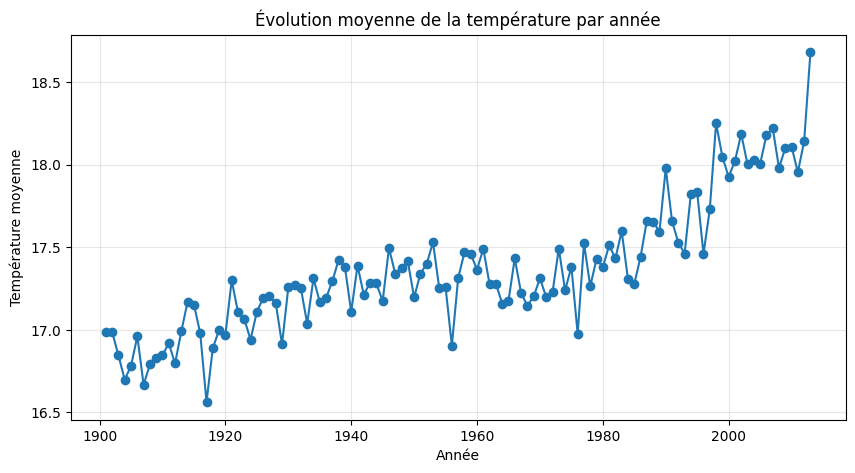

In [22]:
temp_annual_mean = (
    df_temp[df_temp["year"] > 1900]
    .groupby("year", as_index=False)["avg_temp"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(temp_annual_mean["year"], temp_annual_mean["avg_temp"], marker="o")
plt.xlabel("Année")
plt.ylabel("Température moyenne")
plt.title("Évolution moyenne de la température par année")
plt.grid(alpha=0.3)
plt.show()

In [23]:
df_country_temp = (
    df_temp
    .groupby("country")["avg_temp"]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)
df_country_temp.head(10)

,mean,median,max
country,,,
Niger,29.039801,29.070,30.42
Burkina Faso,28.049167,28.060,29.41
Sudan,27.372804,26.985,30.73
Thailand,27.154263,27.135,28.98
Somalia,27.150851,27.140,28.28
Guinea Bissau,27.053861,27.015,28.36
Mauritania,27.023851,26.910,28.70
Mali,26.969557,26.955,28.53
Qatar,26.766707,26.730,29.70


### Doublons

In [24]:
print("lignes                                        :", len(df_temp))
print("doublons exacts, lignes en trop               :", df_temp.duplicated().sum())
print("lignes distinctes apparaissant plusieurs fois :",
      df_temp[df_temp.duplicated(keep=False)].drop_duplicates().shape[0])
print("couples (country, year) non uniques           :", df_temp.duplicated(["country", "year"]).sum())
print("maximum de lignes pour un même couple         :", df_temp.groupby(["country", "year"]).size().max())

sans_doublons = df_temp.drop_duplicates()
print(f"\naprès drop_duplicates : {len(sans_doublons)} lignes")
print("  couples encore dupliqués :", sans_doublons.duplicated(["country", "year"]).sum())

pays_dupliques = df_temp[df_temp.duplicated(keep=False)].groupby("country").size().sort_values(ascending=False)
print(f"\npays concernés : {pays_dupliques.index.nunique()} / {df_temp['country'].nunique()}")
print(pays_dupliques.head(5).to_string())

lignes                                        : 71311
doublons exacts, lignes en trop               : 6958
lignes distinctes apparaissant plusieurs fois : 5005
couples (country, year) non uniques           : 42797
maximum de lignes pour un même couple         : 52

après drop_duplicates : 64353 lignes
  couples encore dupliqués : 35839

pays concernés : 30 / 137
country
United States    4498
India            1577
China            1367
Pakistan         1053
Brazil            778


**Observations :**

- **6 958 lignes en trop** sont des doublons strictement identiques sur les 3 colonnes. Le profiling annonce 5 005 : c'est le nombre de lignes *distinctes* apparaissant plusieurs fois, pas le nombre de lignes à retirer.
- Ils se concentrent sur 30 pays sur 137 : États-Unis (4 498), Inde (1 577), Chine (1 367).
- Leur suppression est justifiée, les lignes étant identiques.
- **Elle ne suffit pas** : après `drop_duplicates`, 35 839 couples `(country, year)` restent en double avec des températures *différentes*, jusqu'à 52 relevés pour un couple. Plusieurs relevés existent donc pour un même couple pays/année, ce qui provoquerait un fan-out lors d'une jointure directe.

### Valeurs manquantes de `avg_temp`

In [25]:
print(f"manquants : {df_temp['avg_temp'].isna().sum()} ({df_temp['avg_temp'].isna().mean():.1%})")

periodes = []
for debut, fin in [(1743, 1799), (1800, 1899), (1900, 1989), (1990, 2013)]:
    extrait = df_temp[(df_temp["year"] >= debut) & (df_temp["year"] <= fin)]
    periodes.append({
        "période": f"{debut}-{fin}",
        "lignes": len(extrait),
        "manquants": extrait["avg_temp"].isna().sum(),
        "taux (%)": round(100 * extrait["avg_temp"].isna().mean(), 1),
    })

pd.DataFrame(periodes)

manquants : 2547 (3.6%)


,période,lignes,manquants,taux (%)
0,1743-1799,5498,613,11.1
1,1800-1899,26483,1934,7.3
2,1900-1989,31050,0,0.0
3,1990-2013,8280,0,0.0


**Observations :**

- Les 2 547 manquants (3,6 %) sont **tous antérieurs à 1900** : 11,1 % au XVIIIᵉ siècle, 7,3 % au XIXᵉ.
- **Aucun manquant à partir de 1900**, donc aucun sur la période qui servira à la fusion.
- Pas d'imputation à prévoir pour `avg_temp`.

## yield.csv

In [26]:
df_yield

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400
...,...,...,...,...,...,...,...,...,...,...,...,...
56712,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2012,2012,hg/ha,24420
56713,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2013,2013,hg/ha,22888
56714,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2014,2014,hg/ha,21357
56715,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2015,2015,hg/ha,19826


In [27]:
p_yield = profile.profile_report(df_yield, PATHS.docs / "eda_yield_rapport.html")

Observations       : 56,717
Variables          : 12
Cellules manquantes: 0 (0.00%)
Lignes dupliquees  : 0 (0.00%)
Taille en memoire  : 5.2 Mo
Types              : {'Text': 6, 'Numeric': 6}

Alertes :
 - [Domain Code] has a constant value
 - [Domain] has a constant value
 - [Element Code] has a constant value
 - [Element] has a constant value
 - [Unit] has a constant value
 - [Year] is highly overall correlated with [Year Code]
 - [Year Code] is highly overall correlated with [Year]


In [28]:
print("Pays : ", df_yield["Area"].nunique())
print(f"Années : {min(df_yield.Year)}-{max(df_yield.Year)} ({df_yield.Year.nunique()} distinctes)")
print(f"Rendement : {min(df_yield.Value)} - {max(df_yield.Value)} (moyenne : {df_yield.Value.mean()})")
print("   -> Nombre = 0 : ",len(df_yield[df_yield.Value == 0]))

Pays :  212
Années : 1961-2016 (56 distinctes)
Rendement : 0 - 1000000 (moyenne : 62094.66008427808)
   -> Nombre = 0 :  8


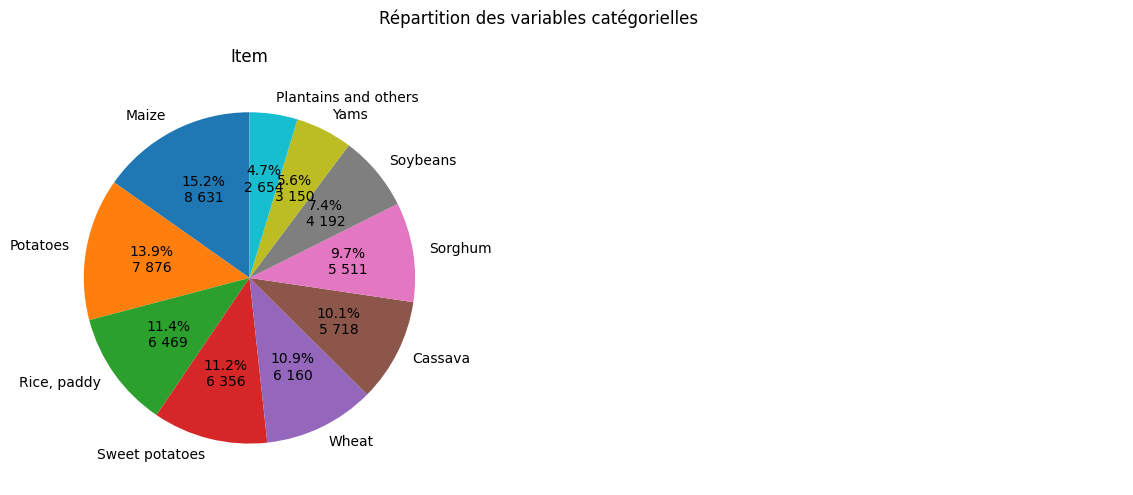

In [29]:
utils.plot_pies(df_yield, ["Item"])

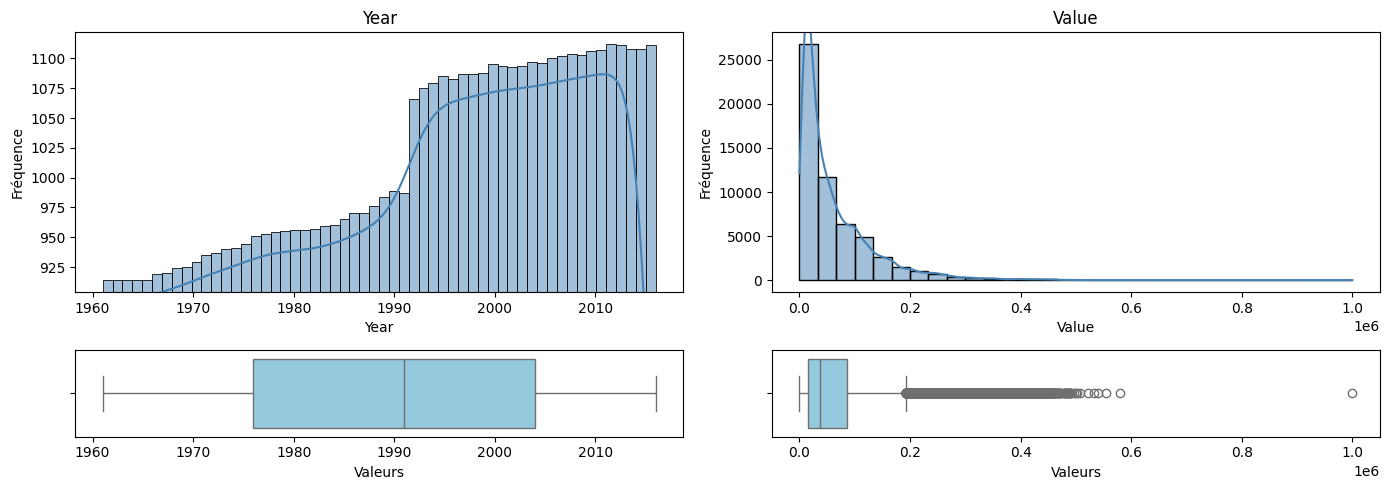

In [30]:
utils.plot_distribs(df_yield, ["Year", "Value"], bins={"Year": df_yield["Year"].nunique()})

In [31]:
df_yield[["Item Code","Item"]].value_counts()

Item Code  Item                
56         Maize                   8631
116        Potatoes                7876
27         Rice, paddy             6469
122        Sweet potatoes          6356
15         Wheat                   6160
125        Cassava                 5718
83         Sorghum                 5511
236        Soybeans                4192
137        Yams                    3150
489        Plantains and others    2654
Name: count, dtype: int64

In [32]:
# Area Code et Item Code sont-ils en correspondance stricte avec les libellés ?
print("Area  :", df_yield.groupby("Area Code")["Area"].nunique().max(), "libellé par code")
print("Item  :", df_yield.groupby("Item Code")["Item"].nunique().max(), "libellé par code")

Area  : 1 libellé par code
Item  : 1 libellé par code


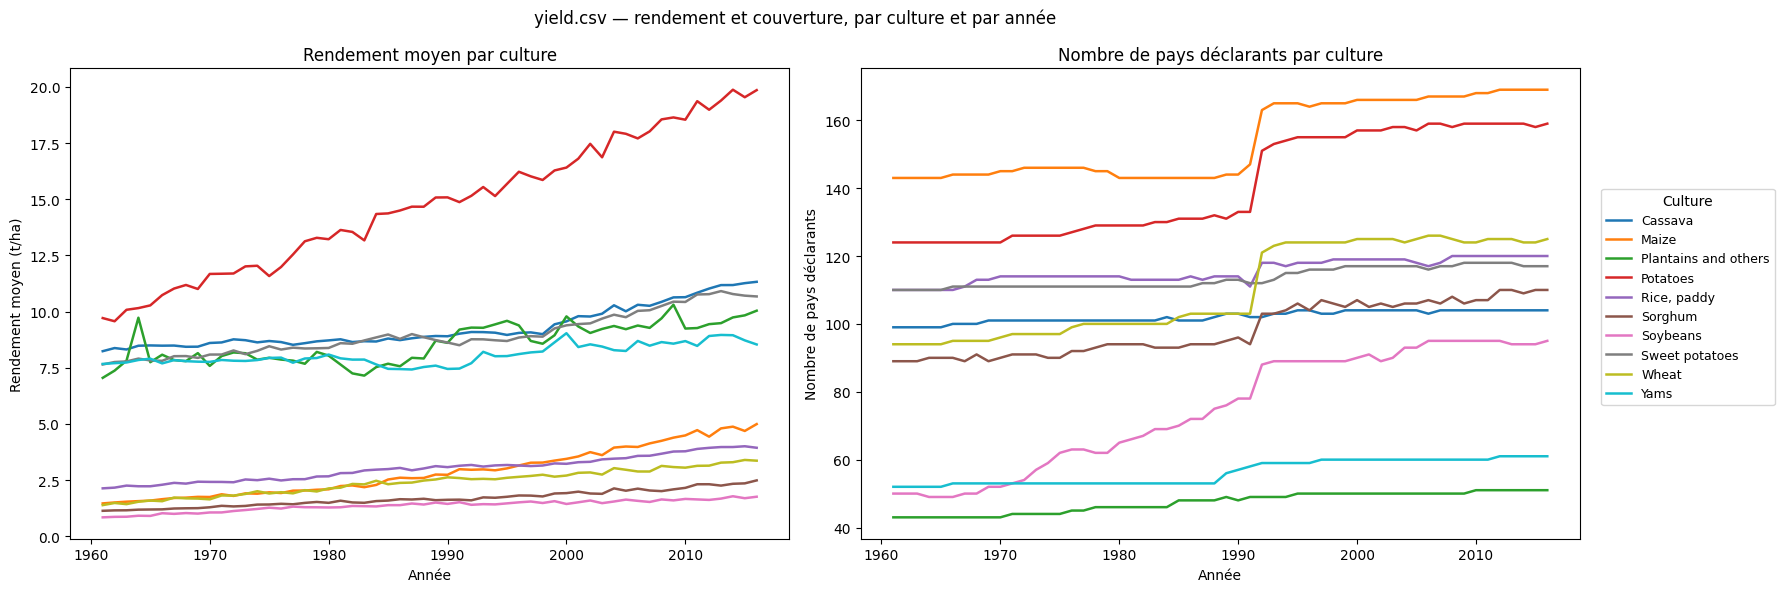

In [33]:
rendement = (
    df_yield.pivot_table(index="Year", columns="Item", values="Value", aggfunc="mean")
    .div(10_000)                                    # hg/ha -> t/ha
)
nb_pays = df_yield.pivot_table(index="Year", columns="Item", values="Area", aggfunc="nunique")
nb_pays = nb_pays[rendement.columns]                # même ordre -> mêmes couleurs des deux côtés

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rendement.plot(ax=axes[0], linewidth=1.8, legend=False)
axes[0].set_ylabel("Rendement moyen (t/ha)")
axes[0].set_xlabel("Année")
axes[0].set_title("Rendement moyen par culture")

nb_pays.plot(ax=axes[1], linewidth=1.8, legend=False)
axes[1].set_ylabel("Nombre de pays déclarants")
axes[1].set_xlabel("Année")
axes[1].set_title("Nombre de pays déclarants par culture")

# Une seule légende pour les deux graphiques
poignees, etiquettes = axes[0].get_legend_handles_labels()
fig.legend(poignees, etiquettes, title="Culture", loc="center left",
           bbox_to_anchor=(1.0, 0.5), fontsize=9)

fig.suptitle("yield.csv — rendement et couverture, par culture et par année")
fig.tight_layout()
plt.show()

**Observations :**

- Deux familles nettement séparées : tubercules (pomme de terre jusqu'à 19,9 t/ha) et céréales / légumineuses (soja 1,8 t/ha), soit un facteur 11 entre les extrêmes.
- C'est le différentiel entre cultures qui manque au jeu de données parcellaire.
- Le nombre de pays déclarants n'est pas stable : marche nette en 1992 sur les cultures tempérées, hausse continue pour le soja (50 → 95 pays).
- Les courbes de rendement doivent donc se lire en tenant compte de cette couverture variable : une hausse peut refléter un changement de panel autant qu'un progrès agronomique.

# Période commune aux sources

In [34]:
bornes = {
    "yield.csv": (df_yield["Year"].min(), df_yield["Year"].max()),
    "rainfall.csv": (df_rainfall["Year"].min(), df_rainfall["Year"].max()),
    "pesticides.csv": (df_pesticides["Year"].min(), df_pesticides["Year"].max()),
    "temp.csv": (df_temp["year"].min(), df_temp["year"].max()),
}

debut = max(a for a, _ in bornes.values())
fin = min(b for _, b in bornes.values())

for fichier, (a, b) in bornes.items():
    print(f"{fichier:16} {a} - {b}")
print(f"\npériode commune  {debut} - {fin}  ({fin - debut + 1} années)")
print(f"yield_df.csv     {df_yield_df['Year'].min()} - {df_yield_df['Year'].max()}")

yield.csv        1961 - 2016
rainfall.csv     1985 - 2017
pesticides.csv   1990 - 2016
temp.csv         1743 - 2013

période commune  1990 - 2013  (24 années)
yield_df.csv     1990 - 2013


**Observations :**

- Période exploitable : **1990-2013**, soit 24 années. `pesticides.csv` fixe la borne basse, `temp.csv` la borne haute.
- C'est exactement l'étendue de `yield_df.csv` : la fusion existante est bien bornée par ces deux fichiers.
- `yield.csv` perd 29 années et `temp.csv` 247 : ces profondeurs d'historique ne serviront pas à la fusion.
- C'est cette période qui doit servir de référence unique pour les analyses destinées à la fusion.

# Couverture géographique

Les quatre fichiers sources ne couvrent pas les mêmes pays, et `yield_df.csv` ne
retient que leur intersection. Les noms sont d'abord ramenés à leur code ISO3,
sinon un même pays écrit différemment d'un fichier à l'autre compte pour deux.

In [35]:
sources = {
    "yield.csv": df_yield["Area"],
    "rainfall.csv": df_rainfall["Area"],
    "pesticides.csv": df_pesticides["Area"],
    "temp.csv": df_temp["country"],
}

# Les variantes d'écriture d'un même pays se rejoignent sur un seul code ISO3
pays = {
    fichier: set(geo.vers_iso3(colonne.astype(str).unique()).values())
    for fichier, colonne in sources.items()
}
retenus = set(geo.vers_iso3(df_yield_df["Area"].astype(str).unique()).values())

communs = set.intersection(*pays.values())
perdus = communs - retenus

for fichier, colonne in sources.items():
    print(f"{fichier:16} {colonne.nunique():4} noms -> {len(pays[fichier]):3} pays cartographiables")

print(f"\nintersection des 4 sources : {len(communs)} pays")
print(f"retenus dans yield_df.csv  : {len(retenus)} pays")
print(f"perdus par la fusion       : {len(perdus)} pays")

yield.csv         212 noms -> 168 pays cartographiables
rainfall.csv      217 noms -> 170 pays cartographiables
pesticides.csv    168 noms -> 144 pays cartographiables
temp.csv          137 noms -> 133 pays cartographiables

intersection des 4 sources : 117 pays
retenus dans yield_df.csv  : 99 pays
perdus par la fusion       : 18 pays


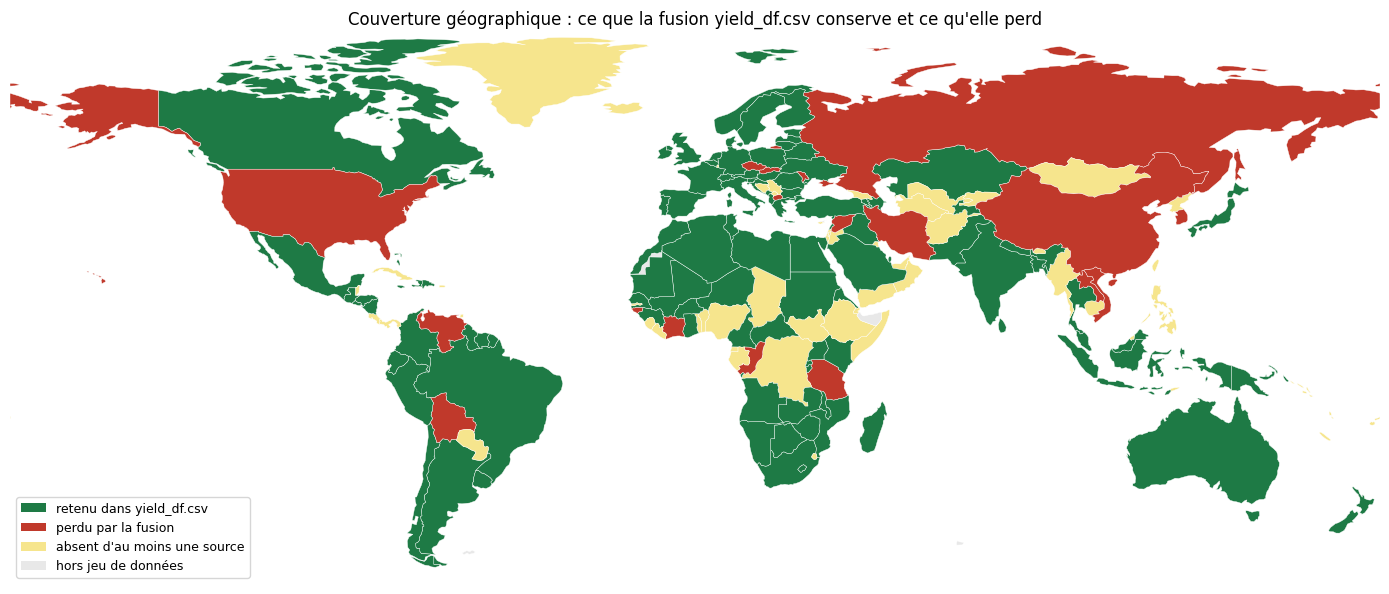

In [36]:
contours = geo.charger_contours()

categories = {}
for code in contours:
    if code in retenus:
        categories[code] = "retenu dans yield_df.csv"
    elif code in perdus:
        categories[code] = "perdu par la fusion"
    elif any(code in codes for codes in pays.values()):
        categories[code] = "absent d'au moins une source"

geo.plot_carte_categories(
    categories,
    couleurs={
        "retenu dans yield_df.csv": "#1e7a45",
        "perdu par la fusion": "#c0392b",
        "absent d'au moins une source": "#f6e58d",
    },
    titre="Couverture géographique : ce que la fusion yield_df.csv conserve et ce qu'elle perd",
    contours=contours,
)

**Observations :**

- `yield_df.csv` retient **99 pays** cartographiables, alors que l'intersection
  réelle des 4 sources en compte **117** : **18 pays sont perdus** bien que les
  quatre fichiers les contiennent.
- Pour ces 18 pays présents dans les quatre sources, la perte vient principalement
  des différences de noms utilisées lors de la jointure :
  `United States of America` / `United States`, `Russian Federation` / `Russia`,
  `China, mainland` / `China`, `Iran (Islamic Republic of)` / `Iran`.
- Les pays perdus sont parmi les premiers producteurs mondiaux : États-Unis,
  Russie, Chine, Iran, Viêt Nam, Tanzanie, Côte d'Ivoire.
- L'Éthiopie et le Nigeria sont en revanche légitimement absents : la première
  manque de `temp.csv`, le second de `pesticides.csv`.
- Deuxième argument, après le défaut de jointure sur `temp.csv`, pour reconstruire
  la fusion plutôt que d'utiliser `yield_df.csv` tel quel.

# Pré-fusion exploratoire

Objectif : mettre les quatre sources à une granularité compatible pour étudier leur comportement
conjoint. Cible : **pays × année × culture**, sur **1990-2013**, l'intersection des quatre fichiers.

Ce n'est pas le dataset final. La période reste à décider — c'est justement ce que cette section
doit éclairer.

## Contrôles préalables

In [37]:
DEBUT, FIN = 1990, 2013

print("granularité native, doublons sur la clé attendue")
print("  pesticides (Area, Year)      :", df_pesticides.duplicated(["Area", "Year"]).sum())
print("  rainfall   (Area, Year)      :", df_rainfall.duplicated(["Area", "Year"]).sum())
print("  yield      (Area, Item, Year):", df_yield.duplicated(["Area", "Item", "Year"]).sum())

print("\nplusieurs noms pointant vers un même code ISO3 :")
for nom, df, col in [("pesticides", df_pesticides, "Area"), ("rainfall", df_rainfall, "Area"),
                     ("temp", df_temp, "country"), ("yield", df_yield, "Area")]:
    codes = geo.vers_iso3(df[col].astype(str).unique())
    noms_par_code = {}
    for nom_pays, code_iso in codes.items():
        noms_par_code.setdefault(code_iso, []).append(nom_pays)
    collisions = {code: noms for code, noms in noms_par_code.items() if len(noms) > 1}
    print(f"  {nom:11} {collisions or 'aucune'}")

granularité native, doublons sur la clé attendue
  pesticides (Area, Year)      : 0
  rainfall   (Area, Year)      : 0
  yield      (Area, Item, Year): 0

plusieurs noms pointant vers un même code ISO3 :
  pesticides  aucune
  rainfall    aucune
  temp        aucune
  yield       {'CHN': ['China', 'China, mainland']}


**Observations :**

- `pesticides.csv` et `rainfall.csv` ont bien **une seule ligne par pays et par année** : aucune agrégation nécessaire.
- `yield.csv` est unique sur `(Area, Item, Year)`.
- Une collision : `China` et `China, mainland` pointent vers le même code. À traiter avant la jointure.

In [38]:
# China = agrégat, China, mainland = Chine continentale seule
chine = df_yield[df_yield["Area"].isin(["China", "China, mainland"])]
compare = chine.pivot_table(index=["Item", "Year"], columns="Area", values="Value")
ecart = (compare["China"] - compare["China, mainland"]).abs() / compare["China, mainland"]

print(f"couples (Item, Year) communs : {len(compare.dropna())}")
print(f"écart relatif moyen          : {ecart.mean():.2%}")

# Quel périmètre les autres sources retiennent-elles pour la Chine ?
print("\nlibellés liés à la Chine, par source :")
for nom, df, colonne in [("yield.csv", df_yield, "Area"), ("rainfall.csv", df_rainfall, "Area"),
                         ("pesticides.csv", df_pesticides, "Area"), ("temp.csv", df_temp, "country")]:
    libelles = sorted(v for v in df[colonne].astype(str).unique()
                      if any(mot in v.lower() for mot in ["china", "hong kong", "macao", "taiwan"]))
    print(f"  {nom:16} {libelles}")

couples (Item, Year) communs : 448
écart relatif moyen          : 0.26%

libellés liés à la Chine, par source :
  yield.csv        ['China', 'China, Hong Kong SAR', 'China, Taiwan Province of', 'China, mainland']
  rainfall.csv     ['China', 'Hong Kong SAR, China', 'Macao SAR, China']
  pesticides.csv   ['China, Hong Kong SAR', 'China, Macao SAR', 'China, Taiwan Province of', 'China, mainland']
  temp.csv         ['China', 'Hong Kong', 'Taiwan']


**Observations :**

- Les deux entités se recouvrent sur **448 couples** `(culture, année)`, avec un écart relatif moyen de **0,26 %**.
- Les trois autres sources isolent Hong Kong, Macao ou Taïwan comme entités distinctes. `pesticides.csv` n'a d'ailleurs **pas** de libellé `China`, seulement `China, mainland` : le code `CHN` y désigne donc la **Chine continentale**.
- On garde **`China, mainland`** côté rendement, pour joindre des périmètres comparables ; l'agrégat `China` est écarté.

## Préparation des sources

In [39]:
def ajoute_iso3(df, colonne_pays):
    """Ajoute une colonne iso3 à partir du nom de pays."""
    correspondances = geo.vers_iso3(df[colonne_pays].astype(str).unique())
    return df.assign(iso3=df[colonne_pays].map(correspondances))


# Rendement : base de la fusion, granularité pays x année x culture
rendement = (
    df_yield[df_yield["Area"] != "China"]
    .query("@DEBUT <= Year <= @FIN")
    .pipe(ajoute_iso3, "Area")
    .rename(columns={"Area": "area", "Year": "year", "Item": "crop"})
    .assign(yield_t_ha=lambda d: d["Value"] / 10_000)
    [["iso3", "area", "year", "crop", "yield_t_ha"]]
)

# Température : doublons exacts retirés, puis moyenne des relevés d'un pays et d'une année
temperature = (
    df_temp.drop_duplicates()
    .query("@DEBUT <= year <= @FIN")
    .pipe(ajoute_iso3, "country")
    .groupby(["iso3", "year"], as_index=False)["avg_temp"].mean()
)

# Pluie et pesticides : déjà à la granularité pays x année
pluie = (
    df_rainfall.query("@DEBUT <= Year <= @FIN")
    .pipe(ajoute_iso3, "Area")
    .rename(columns={"Year": "year", "average_rain_fall_mm_per_year": "rain_mm"})
    [["iso3", "year", "rain_mm"]]
)

pesticides = (
    df_pesticides.query("@DEBUT <= Year <= @FIN")
    .pipe(ajoute_iso3, "Area")
    .rename(columns={"Year": "year", "Value": "pesticides_t"})
    [["iso3", "year", "pesticides_t"]]
)

La moyenne représente les relevés disponibles pour le pays et l'année, sans pondération géographique.

In [40]:
# Noms sans code ISO3 : on regarde ce qu'on écarte avant de le faire
for nom, prepare, colonne in [("rendement", rendement, "area"), ("température", temperature, None),
                              ("pluie", pluie, None), ("pesticides", pesticides, None)]:
    perdues = prepare["iso3"].isna().sum()
    print(f"{nom:12} {len(prepare):6} lignes | sans ISO3 : {perdues:5} ({perdues/len(prepare):.1%})")

noms_perdus = sorted(rendement.loc[rendement["iso3"].isna(), "area"].unique())
print(f"\npays du rendement sans contour ISO3 ({len(noms_perdus)}) :")
print(", ".join(noms_perdus))

rendement     25848 lignes | sans ISO3 :  3169 (12.3%)
température    3192 lignes | sans ISO3 :     0 (0.0%)
pluie          4991 lignes | sans ISO3 :  1081 (21.7%)
pesticides     3860 lignes | sans ISO3 :   506 (13.1%)

pays du rendement sans contour ISO3 (43) :
American Samoa, Antigua and Barbuda, Bahrain, Barbados, Belgium-Luxembourg, Bermuda, Cabo Verde, Cayman Islands, China, Hong Kong SAR, China, Taiwan Province of, Comoros, Cook Islands, Czechoslovakia, Dominica, Ethiopia PDR, Faroe Islands, French Guiana, French Polynesia, Grenada, Guadeloupe, Guam, Maldives, Malta, Martinique, Mauritius, Micronesia (Federated States of), Montserrat, Niue, Pacific Islands Trust Territory, Réunion, Saint Kitts and Nevis, Saint Lucia, Saint Vincent and the Grenadines, Samoa, Sao Tome and Principe, Serbia and Montenegro, Seychelles, Singapore, Sudan (former), Tonga, USSR, Wallis and Futuna Islands, Yugoslav SFR


**Observations :**

- Les lignes sans code ISO3 correspondent aux micro-États, territoires insulaires et entités historiques déjà repérés : sans contour à l'échelle utilisée, mais surtout absents des autres sources.
- Elles sont écartées de la pré-fusion, pas des fichiers sources.

## Fusion

In [41]:
prefusion = rendement.dropna(subset=["iso3"])

for nom, source in [("pluie", pluie), ("température", temperature), ("pesticides", pesticides)]:
    avant = len(prefusion)
    prefusion = prefusion.merge(source.dropna(subset=["iso3"]), on=["iso3", "year"], how="left")
    print(f"+ {nom:12} {avant} -> {len(prefusion)} lignes")

cle_unique = not prefusion.duplicated(["iso3", "year", "crop"]).any()
print(f"\nlignes    : {len(prefusion)}")
print(f"pays      : {prefusion['iso3'].nunique()}")
print(f"cultures  : {prefusion['crop'].nunique()}")
print(f"années    : {prefusion['year'].min()} - {prefusion['year'].max()}")
print(f"clé (iso3, year, crop) unique : {cle_unique}")

assert cle_unique, "fan-out : la clé attendue n'est pas unique"

+ pluie        22679 -> 22679 lignes
+ température  22679 -> 22679 lignes
+ pesticides   22679 -> 22679 lignes

lignes    : 22679
pays      : 168
cultures  : 10
années    : 1990 - 2013
clé (iso3, year, crop) unique : True


In [42]:
print("taux de valeurs manquantes (%) :")
print((prefusion.isna().mean() * 100).round(1).to_string())

complet = prefusion.dropna()
print(f"\nlignes complètes : {len(complet)} ({len(complet)/len(prefusion):.1%})")
print(f"pays si on ne gardait que ces lignes : {complet['iso3'].nunique()}")

taux de valeurs manquantes (%) :
iso3             0.0
area             0.0
year             0.0
crop             0.0
yield_t_ha       0.0
rain_mm          5.0
avg_temp        19.5
pesticides_t    13.1

lignes complètes : 15664 (69.1%)
pays si on ne gardait que ces lignes : 117


**Observations :**

- **22 679 lignes**, 168 pays, 10 cultures, 24 années. Aucun fan-out : le nombre de lignes ne bouge pas au fil des jointures.
- Manquants : température **19,5 %**, pesticides **13,1 %**, pluie **5,0 %**, rendement complet.
- **69,1 % des lignes sont complètes**, pour 117 pays — l'écart avec les 168 mesure ce que coûterait une jointure stricte.
- Aucun pays n'est retiré à ce stade, y compris ceux sans pluie.

## Évolution du rendement par culture

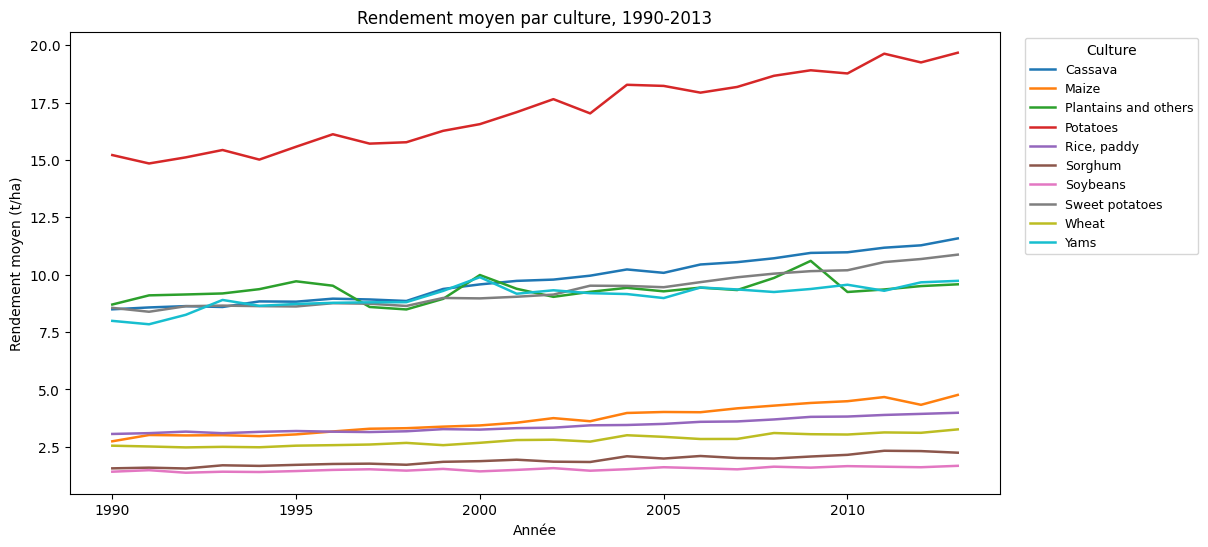

In [43]:
rendement_annuel = prefusion.pivot_table(index="year", columns="crop", values="yield_t_ha", aggfunc="mean")

ax = rendement_annuel.plot(figsize=(12, 6), linewidth=1.8)
ax.set_xlabel("Année")
ax.set_ylabel("Rendement moyen (t/ha)")
ax.set_title("Rendement moyen par culture, 1990-2013")
ax.legend(title="Culture", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.show()

**Observations :**

- Toutes les cultures progressent sur la période, sans rupture visible.
- Les deux familles restent nettement séparées : tubercules autour de 9 à 19 t/ha, céréales et légumineuses entre 1,5 et 5 t/ha.
- L'écart entre cultures reste bien plus grand que l'évolution de chacune dans le temps.
- La couverture géographique varie sur la période : l'interprétation est reprise plus bas.

## Effet de l'année

In [44]:
correlations = (
    prefusion.groupby("crop")
    .apply(lambda g: g["year"].corr(g["yield_t_ha"]), include_groups=False)
    .rename("corr_year_yield")
    .sort_values(ascending=False)
    .to_frame()
)
correlations.round(3)

,corr_year_yield
crop,
Cassava,0.180
Maize,0.155
Potatoes,0.153
"Rice, paddy",0.150
Wheat,0.121
Sorghum,0.106
Sweet potatoes,0.100
Soybeans,0.099
Yams,0.089


**Observations :**

- Corrélations **faibles partout** : de 0,026 (plantain) à 0,180 (manioc).
- `Year` porte donc peu d'information à elle seule : la variabilité entre pays domine largement l'évolution temporelle.
- L'effet varie selon la culture, mais reste du même ordre de grandeur.

## Comparaison de périodes

In [45]:
periodes = prefusion.assign(
    periode=pd.cut(prefusion["year"], [1989, 1999, 2009, 2013],
                   labels=["1990-1999", "2000-2009", "2010-2013"])
)

par_periode = periodes.pivot_table(index="crop", columns="periode", values="yield_t_ha",
                                   aggfunc="mean", observed=True)
par_periode["évolution (%)"] = (
    (par_periode["2010-2013"] / par_periode["1990-1999"] - 1) * 100
).round(1)

par_periode.round(2).sort_values("évolution (%)", ascending=False)

periode,1990-1999,2000-2009,2010-2013,évolution (%)
crop,,,,
Maize,3.10,3.93,4.56,47.2
Sorghum,1.69,1.98,2.26,33.6
Cassava,8.81,10.20,11.26,27.8
Potatoes,15.53,17.86,19.33,24.5
"Rice, paddy",3.15,3.50,3.91,24.0
Wheat,2.55,2.88,3.14,22.9
Sweet potatoes,8.66,9.54,10.58,22.1
Soybeans,1.46,1.54,1.65,12.9
Yams,8.62,9.32,9.57,11.1


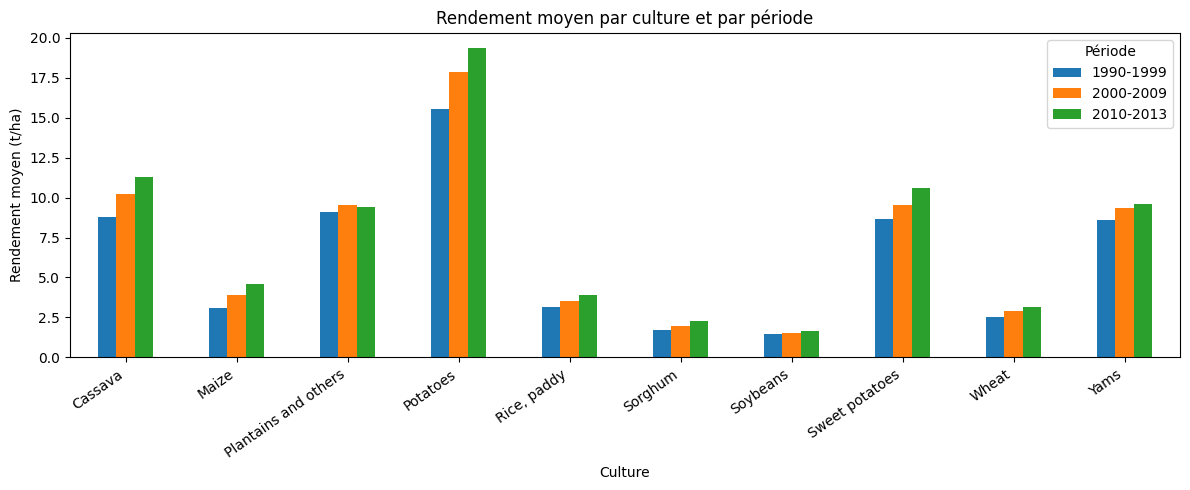

In [46]:
ax = par_periode.drop(columns="évolution (%)").plot(kind="bar", figsize=(12, 5))
ax.set_xlabel("Culture")
ax.set_ylabel("Rendement moyen (t/ha)")
ax.set_title("Rendement moyen par culture et par période")
ax.legend(title="Période")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Observations :**

- Toutes les cultures gagnent entre les années 1990 et 2010-2013 : maïs **+47,2 %**, sorgho +33,6 %, manioc +27,8 %, pomme de terre +24,5 %.
- Deux exceptions basses : plantain **+3,8 %** et igname +11,1 %.
- Les années 1990 se situent donc à un niveau nettement inférieur aux dernières années disponibles.
- 2010-2013 ne compte que 4 années : les niveaux sont comparables, pas les volumes de lignes.

## Climat et pesticides dans le temps

pays ayant une valeur de pluie : 167 / 168
dont une seule valeur sur les 24 ans : 167


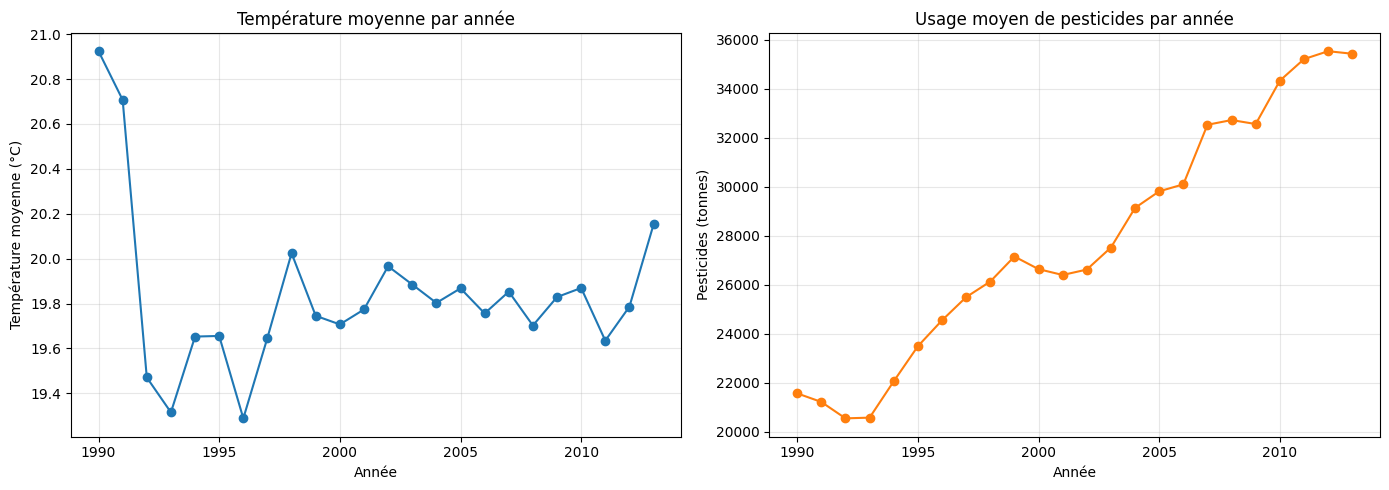

In [47]:
# La pluie varie-t-elle d'une année sur l'autre pour un même pays ?
valeurs_par_pays = prefusion.groupby("iso3")["rain_mm"].nunique(dropna=True)
avec_valeur = valeurs_par_pays[valeurs_par_pays > 0]
print(f"pays ayant une valeur de pluie : {len(avec_valeur)} / {prefusion['iso3'].nunique()}")
print(f"dont une seule valeur sur les 24 ans : {(avec_valeur == 1).sum()}")

annuel = prefusion.groupby("year")[["avg_temp", "pesticides_t"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
annuel["avg_temp"].plot(ax=axes[0], marker="o")
axes[0].set_ylabel("Température moyenne (°C)")
axes[0].set_title("Température moyenne par année")
annuel["pesticides_t"].plot(ax=axes[1], marker="o", color="tab:orange")
axes[1].set_ylabel("Pesticides (tonnes)")
axes[1].set_title("Usage moyen de pesticides par année")
for ax in axes:
    ax.set_xlabel("Année")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**Observations :**

- **`rain_mm` est constante sur les 24 années** pour les 167 pays qui en ont une : c'est une normale climatique répétée, pas une mesure annuelle. Elle ne peut porter aucune dérive temporelle et n'est donc pas tracée.
- La température moyenne **baisse** de 21,1 à 20,3 °C entre 1990 et 2013 — résultat contre-intuitif, examiné dans la section suivante.
- Les pesticides passent de 21 000 à 35 300 tonnes en moyenne par pays, soit environ **+68 %**.

## Contrôle de la composition géographique

pays par année : 138 (1990) -> 168 (2012)
panel constant : 138 pays sur 168


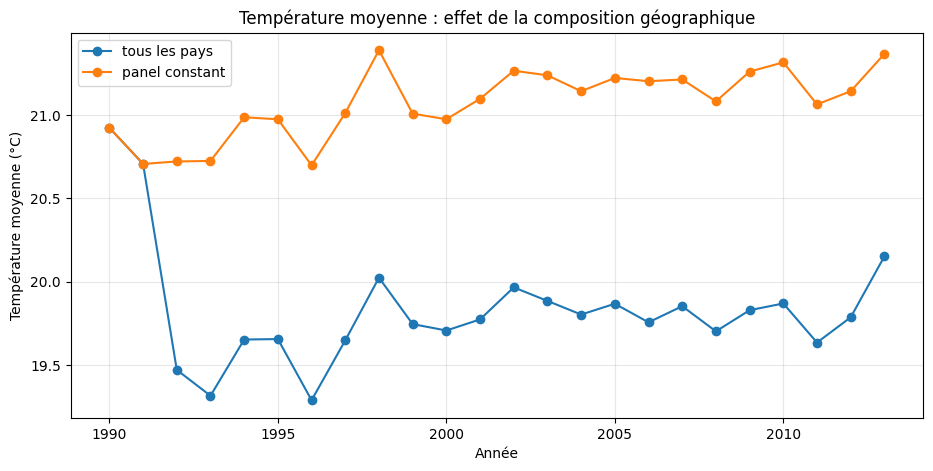

tous les pays    1990 -> 2013 : -0.77 °C
panel constant   1990 -> 2013 : +0.44 °C


In [48]:
pays_par_an = prefusion.groupby("year")["iso3"].nunique()
print(f"pays par année : {pays_par_an.min()} ({pays_par_an.idxmin()}) -> "
      f"{pays_par_an.max()} ({pays_par_an.idxmax()})")

# Panel constant : pays présents toutes les années de la période
stables = (
    prefusion.groupby("iso3")["year"].nunique()
    .pipe(lambda s: s[s == prefusion["year"].nunique()].index)
)
panel = prefusion[prefusion["iso3"].isin(stables)]
print(f"panel constant : {len(stables)} pays sur {prefusion['iso3'].nunique()}")

comparaison = pd.DataFrame({
    "tous les pays": prefusion.groupby("year")["avg_temp"].mean(),
    "panel constant": panel.groupby("year")["avg_temp"].mean(),
})

ax = comparaison.plot(figsize=(11, 5), marker="o")
ax.set_xlabel("Année")
ax.set_ylabel("Température moyenne (°C)")
ax.set_title("Température moyenne : effet de la composition géographique")
ax.grid(alpha=0.3)
plt.show()

for colonne in comparaison:
    ecart = comparaison[colonne].loc[2013] - comparaison[colonne].loc[1990]
    print(f"{colonne:16} 1990 -> 2013 : {ecart:+.2f} °C")

In [49]:
# Le nombre de pays déclarants par culture est-il stable ?
prefusion.pivot_table(index="year", columns="crop", values="iso3", aggfunc="nunique").loc[[1990, 1992, 2000, 2013]]

crop,Cassava,Maize,Plantains and others,Potatoes,"Rice, paddy",Sorghum,Soybeans,Sweet potatoes,Wheat,Yams
year,,,,,,,,,,
1990,75,122,39,113,102,87,72,84,94,38
1992,75,141,41,132,111,96,83,84,113,40
2000,75,147,41,141,111,101,87,90,120,42
2013,76,152,42,145,112,106,92,92,122,44


In [50]:
# Les hausses de rendement résistent-elles au panel constant ?
periodes_panel = panel.assign(
    periode=pd.cut(panel["year"], [1989, 1999, 2009, 2013],
                   labels=["1990-1999", "2000-2009", "2010-2013"])
)
evolution_panel = periodes_panel.pivot_table(index="crop", columns="periode", values="yield_t_ha",
                                             aggfunc="mean", observed=True)

pd.DataFrame({
    "tous les pays (%)": par_periode["évolution (%)"],
    "panel constant (%)": ((evolution_panel["2010-2013"] / evolution_panel["1990-1999"] - 1) * 100).round(1),
}).sort_values("tous les pays (%)", ascending=False)

,tous les pays (%),panel constant (%)
crop,,
Maize,47.2,41.6
Sorghum,33.6,32.9
Cassava,27.8,28.5
Potatoes,24.5,21.6
"Rice, paddy",24.0,21.7
Wheat,22.9,19.1
Sweet potatoes,22.1,20.2
Soybeans,12.9,7.3
Yams,11.1,10.5


**Observations :**

- La couverture passe de **138 pays en 1990 à 168 en 2013**, avec une marche en 1992.
- La chute 1990-1992 de la température vient du **changement de panel**, pas d'une baisse climatique observée.
- Sur panel constant, la température moyenne augmente de **+0,44 °C** entre 1990 et 2013. Les années 1990-1991, à couverture la plus faible, sont donc moins comparables au reste de la série brute.
- Les hausses restent visibles à panel constant : maïs +47,2 % contre +41,6 %, blé +22,9 % contre +19,1 %.
- Les corrélations `Year` / rendement sont quasi inchangées à panel constant.